# Feature selection analysis

To be written (and then copy pasted in the doc)


### Loading the dataset

The code for this process is hidden by default, as it is the same process done by model_exploration


In [ ]:
import pandas as pd
import sys

# load data set
df = pd.read_csv("../NPFC-Test_Database_V2.csv")

relevant_columns = [
    "Subject_ID",
    "Timestamp",
    "Test_Time",
    "Task_Num",
    "Task_Time",
    "Task_Type",
    "Frame",
    "Task_Frame",
    "Selfreport_valence",
    "Selfreport_arousal",
    "Selfreport_focus",
    "Face_Detection",
    "resmasknet_anger",
    "resmasknet_disgust",
    "resmasknet_fear",
    "resmasknet_happiness",
    "resmasknet_sadness",
    "resmasknet_surprise",
    "resmasknet_neutral",
    "Temperature",
    "EDA",
    "BVP",
    "HeadBandOn",
    "Delta_TP9",
    "Delta_AF7",
    "Delta_AF8",
    "Delta_TP10",
    "Theta_TP9",
    "Theta_AF7",
    "Theta_AF8",
    "Theta_TP10",
    "Alpha_TP9",
    "Alpha_AF7",
    "Alpha_AF8",
    "Alpha_TP10",
    "Beta_TP9",
    "Beta_AF7",
    "Beta_AF8",
    "Beta_TP10",
    "Gamma_TP9",
    "Gamma_AF7",
    "Gamma_AF8",
    "Gamma_TP10",
    "Gender",
    "Perceived_Tiredness",
    "Perceived_Stress",
    "Wearing_Glasses",
]

df = df[relevant_columns]


In [ ]:
sys.path.append("./data-preprocessing")
from data_preparation import (
    prepare_data,
    normalize_signals_with_mediation_baseline,
    align_lag_signals,
)

# Clean, normalize and align data based on exploratory data analysis and domain knowledge
df = normalize_signals_with_mediation_baseline(df)
df = align_lag_signals(df)
df = prepare_data(df)


In [ ]:
from feature_selection import correlation_based_selection, variance_treshold_selection

# Grab resmasknet_dominant_emotion if you also want the emotion
result_df_regression = df["resmasknet_max_emotion_value"]

# Select relevant features
feature_columns = [
    "Selfreport_valence",
    "Selfreport_arousal",
    "Selfreport_focus",
    "Temperature",
    "EDA",
    "BVP",
    "Delta_TP9",
    "Delta_AF7",
    "Delta_AF8",
    "Delta_TP10",
    "Theta_TP9",
    "Theta_AF7",
    "Theta_AF8",
    "Theta_TP10",
    "Alpha_TP9",
    "Alpha_AF7",
    "Alpha_AF8",
    "Alpha_TP10",
    "Beta_TP9",
    "Beta_AF7",
    "Beta_AF8",
    "Beta_TP10",
    "Gamma_TP9",
    "Gamma_AF7",
    "Gamma_AF8",
    "Gamma_TP10",
    "Gender",
    "Perceived_Tiredness",
    "Perceived_Stress",
    "Wearing_Glasses",
]

feature_df = df[feature_columns]
feature_df = correlation_based_selection(feature_df, threshold=0.9)
feature_df = variance_treshold_selection(feature_df)

# Correlation analysis

Here we analyze if a pair of 2 features have a high correlation between them.

If 2 features have a very high correlation it would mean that one feature can be highly predicted by the other. Therefore, if we included both features that were very highly correlated, it would not add a lot of information to the model.

First we do the correlation matrix and then we graph the correlations in a histogram.


In [ ]:
import numpy as np

# 2. Compute the absolute correlation matrix
corr_matrix = feature_df.corr().abs()

# 3. Select the upper triangle of the correlation matrix
# (We do this to avoid looking at self-correlation (1.0) on the diagonal
# and to avoid checking the same pair twice, e.g., (F1, F2) and (F2, F1))
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 4. Find features with a correlation greater than the selected threshold
threshold = 0.90
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > threshold)]

# 5. Drop the redundant features
df_filtered = df.drop(columns=to_drop)

# --- Output Results ---
print("--- Absolute Correlation Matrix ---")
print(corr_matrix)
print("\n--- Upper Triangle (Isolated Pairs) ---")
print(upper_tri)
print(f"\nFeatures identified for removal (threshold > {threshold}): {to_drop}")
print(f"\nRemaining features shape: {df_filtered.shape}")

--- Absolute Correlation Matrix ---
                      Selfreport_valence  Selfreport_arousal  \
Selfreport_valence              1.000000            0.660106   
Selfreport_arousal              0.660106            1.000000   
Selfreport_focus                0.669002            0.634366   
resmasknet_anger                0.050105            0.093200   
resmasknet_disgust              0.032601            0.010193   
resmasknet_fear                 0.053472            0.001525   
resmasknet_happiness            0.010846            0.068276   
resmasknet_sadness              0.046520            0.017588   
resmasknet_surprise             0.059752            0.060732   
resmasknet_neutral              0.086140            0.020558   
Temperature                     0.041757            0.038989   
EDA                             0.037548            0.097258   
BVP                             0.003982            0.004017   
Delta_TP9                       0.006701            0.022034   
Delt

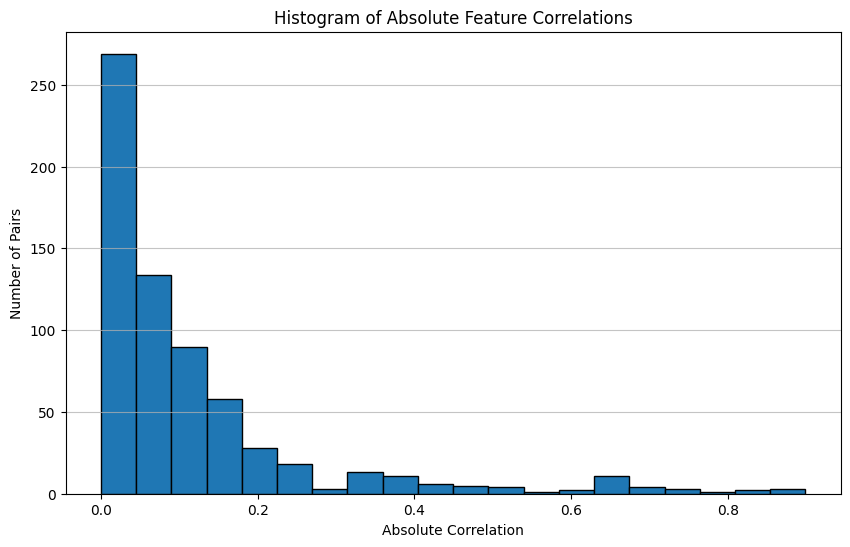

In [ ]:
import matplotlib.pyplot as plt

# Extract all valid (non-NaN) correlation values from the upper triangle
corr_values = upper_tri.values.flatten()
corr_values = corr_values[~np.isnan(corr_values)]

# Plot the histogram
plt.figure(figsize=(10, 6))
# You can adjust the number of bins as needed
plt.hist(corr_values, bins=20, edgecolor="black")
plt.title("Histogram of Absolute Feature Correlations")
plt.xlabel("Absolute Correlation")
plt.ylabel("Number of Pairs")
plt.grid(axis="y", alpha=0.75)
plt.show()

In [ ]:
# Define the threshold variable
corr_threshold = 0.60

# Convert the upper triangle matrix into a tabular format (Feature 1, Feature 2, Correlation)
corr_pairs = upper_tri.stack().reset_index()
corr_pairs.columns = ["Feature 1", "Feature 2", "Correlation"]

# Filter the pairs based on the threshold and sort them in descending order
high_corr_pairs = corr_pairs[corr_pairs["Correlation"] > corr_threshold].sort_values(
    by="Correlation", ascending=False
)

# Reset the index for a cleaner look
high_corr_pairs = high_corr_pairs.reset_index(drop=True)

print(f"Feature pairs with an absolute correlation higher than {corr_threshold}:")
display(high_corr_pairs)

Feature pairs with an absolute correlation higher than 0.6:


,Feature 1,Feature 2,Correlation
0,Theta_AF7,Alpha_AF7,0.898716
1,Delta_AF7,Theta_AF7,0.883060
2,Beta_AF7,Gamma_AF7,0.882102
3,Beta_AF8,Gamma_AF8,0.846490
4,Delta_AF7,Alpha_AF7,0.833525
5,Alpha_AF7,Beta_AF7,0.770017
6,Theta_AF8,Alpha_AF8,0.737013
7,Gamma_TP9,Gamma_TP10,0.725018
8,Delta_AF8,Theta_AF8,0.721164
9,Delta_TP9,Theta_TP9,0.710931


### Correlation analysis result

The feature pairs with highest correlation are the brainwaves features. Although these feature pairs have high correlation, the literature has shown in the past that different brainwaves frequencies have been associated with different emotions and feelings. The are most likely highly correlated due being measured in the same area of the brain (Anterior Frontal OR Temporoparietal regions of the head). We believe that these could still give the model valuable information abuot the subject, so they were kept for the initial model training.

After those, the next highest is between Selfreport_valence and Selfreport_focus, with 0.669 correlation value, which is a moderate correlation between two very relevant features of the dataset. We believe this correlation value is not suficient to justify removing either of the selfreport features, considering they are direct values obtained from the participant.

In conclusion, the feature correlation analysis did not give sufficient evidence to remove any feature from a high correlation feature pair.
